#  Analyse Comparative des Campagnes

## Objectif
Ce notebook se concentre sur la **comparaison détaillée entre les Campagnes 5, 6 et 7** pour identifier:
- Les différences de performance entre campagnes
- L'évolution des paramètres dans le temps
- Les améliorations ou dégradations
- Les patterns spécifiques à chaque campagne

## Questions Clés
1. Quelle campagne a les meilleures performances?
2. Y a-t-il une amélioration progressive entre les campagnes?
3. Quels cristalliseurs performent mieux dans quelle campagne?
4. Y a-t-il des anomalies spécifiques à certaines campagnes?


---
## 1. Configuration et Chargement

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

print('✓ Configuration terminée')

✓ Configuration terminée


In [13]:
# Fonction d'harmonisation des noms de colonnes
def harmonize_columns(df, campaign_name=''):
    '''Harmonise les noms de colonnes en ajoutant le préfixe AVG_ si nécessaire'''
    rename_map = {}
    for col in df.columns:
        if col.startswith('826') and not any(col.startswith(prefix) for prefix in ['AVG_', 'MIN_', 'MAX_', 'STDDEV_']):
            rename_map[col] = f'AVG_{col}'
    
    if rename_map:
        print(f'  {campaign_name}: {len(rename_map)} colonnes harmonisées')
    return df.rename(columns=rename_map)

# Chargement des données des 3 campagnes
print('=== Chargement et Harmonisation des Données ===')

campaign5 = pd.read_csv('T826_CRYSTALLIZER_CAMPAIGN_5_PIVOTBYHOUR.csv')
campaign5 = harmonize_columns(campaign5, 'Campagne 5')
campaign5['CAMPAIGN'] = 'Campagne 5'
campaign5['CAMPAIGN_NUM'] = 5

campaign6 = pd.read_csv('T826_CRYSTALLIZER_CAMPAIGN_6_PIVOTBYHOUR.csv')
campaign6 = harmonize_columns(campaign6, 'Campagne 6')
campaign6['CAMPAIGN'] = 'Campagne 6'
campaign6['CAMPAIGN_NUM'] = 6

campaign7 = pd.read_csv('T826_CRYSTALLIZER_CAMPAIGN_7_PIVOT.csv')
campaign7 = harmonize_columns(campaign7, 'Campagne 7')
campaign7['CAMPAIGN'] = 'Campagne 7'
campaign7['CAMPAIGN_NUM'] = 7

# Conversion des timestamps
for df in [campaign5, campaign6, campaign7]:
    if 'INSTRUMENT_TAG_TS' in df.columns:
        df['TIMESTAMP'] = pd.to_datetime(df['INSTRUMENT_TAG_TS'])

print(f'\n✓ Campagne 5: {len(campaign5)} observations')
print(f'✓ Campagne 6: {len(campaign6)} observations')
print(f'✓ Campagne 7: {len(campaign7)} observations')

# Consolidation
all_data = pd.concat([campaign5, campaign6, campaign7], ignore_index=True)
print(f'\n✓ Total: {len(all_data)} observations')

# Détecter les colonnes disponibles
temp_cols = sorted([col for col in all_data.columns if 'TRC' in col and 'AVG' in col and 'DELTAT' not in col and 'DeltaT' not in col])
level_cols = sorted([col for col in all_data.columns if 'LR' in col and 'AVG' in col])

print(f'\n=== Colonnes Détectées ===')
print(f'Températures ({len(temp_cols)}): {temp_cols}')
print(f'Niveaux ({len(level_cols)}): {level_cols}')

# Créer les noms de cristalliseurs dynamiquement
crystallizers = [f'Cristalliseur {i+1}' for i in range(len(temp_cols))]

=== Chargement et Harmonisation des Données ===
  Campagne 7: 13 colonnes harmonisées

✓ Campagne 5: 374 observations
✓ Campagne 6: 464 observations
✓ Campagne 7: 852471 observations

✓ Total: 853309 observations

=== Colonnes Détectées ===
Températures (3): ['AVG_826TRC07', 'AVG_826TRC08', 'AVG_826TRC09']
Niveaux (2): ['AVG_826LR05', 'AVG_826LR06']


---
## 2. Vue d'Ensemble des Campagnes

In [14]:
print('=== STATISTIQUES GÉNÉRALES PAR CAMPAGNE ===')
print('\nNombre d\'observations:')
print(all_data['CAMPAIGN'].value_counts().sort_index())

print('\nPériode de chaque campagne:')
for campaign in ['Campagne 5', 'Campagne 6', 'Campagne 7']:
    camp_data = all_data[all_data['CAMPAIGN'] == campaign]
    if 'TIMESTAMP' in camp_data.columns and camp_data['TIMESTAMP'].notna().any():
        print(f'{campaign}:')
        print(f'  Début: {camp_data["TIMESTAMP"].min()}')
        print(f'  Fin: {camp_data["TIMESTAMP"].max()}')
        duration = camp_data['TIMESTAMP'].max() - camp_data['TIMESTAMP'].min()
        print(f'  Durée: {duration}')
        print()

=== STATISTIQUES GÉNÉRALES PAR CAMPAGNE ===

Nombre d'observations:
CAMPAIGN
Campagne 5       374
Campagne 6       464
Campagne 7    852471
Name: count, dtype: int64

Période de chaque campagne:
Campagne 5:
  Début: 2025-08-27 11:00:00
  Fin: 2025-09-12 00:00:00
  Durée: 15 days 13:00:00

Campagne 6:
  Début: 2025-11-02 12:00:00
  Fin: 2025-11-22 00:00:00
  Durée: 19 days 12:00:00

Campagne 7:
  Début: 2025-11-30 12:00:00
  Fin: 2025-12-10 11:01:50
  Durée: 9 days 23:01:50



---
## 3. Comparaison des Températures par Campagne

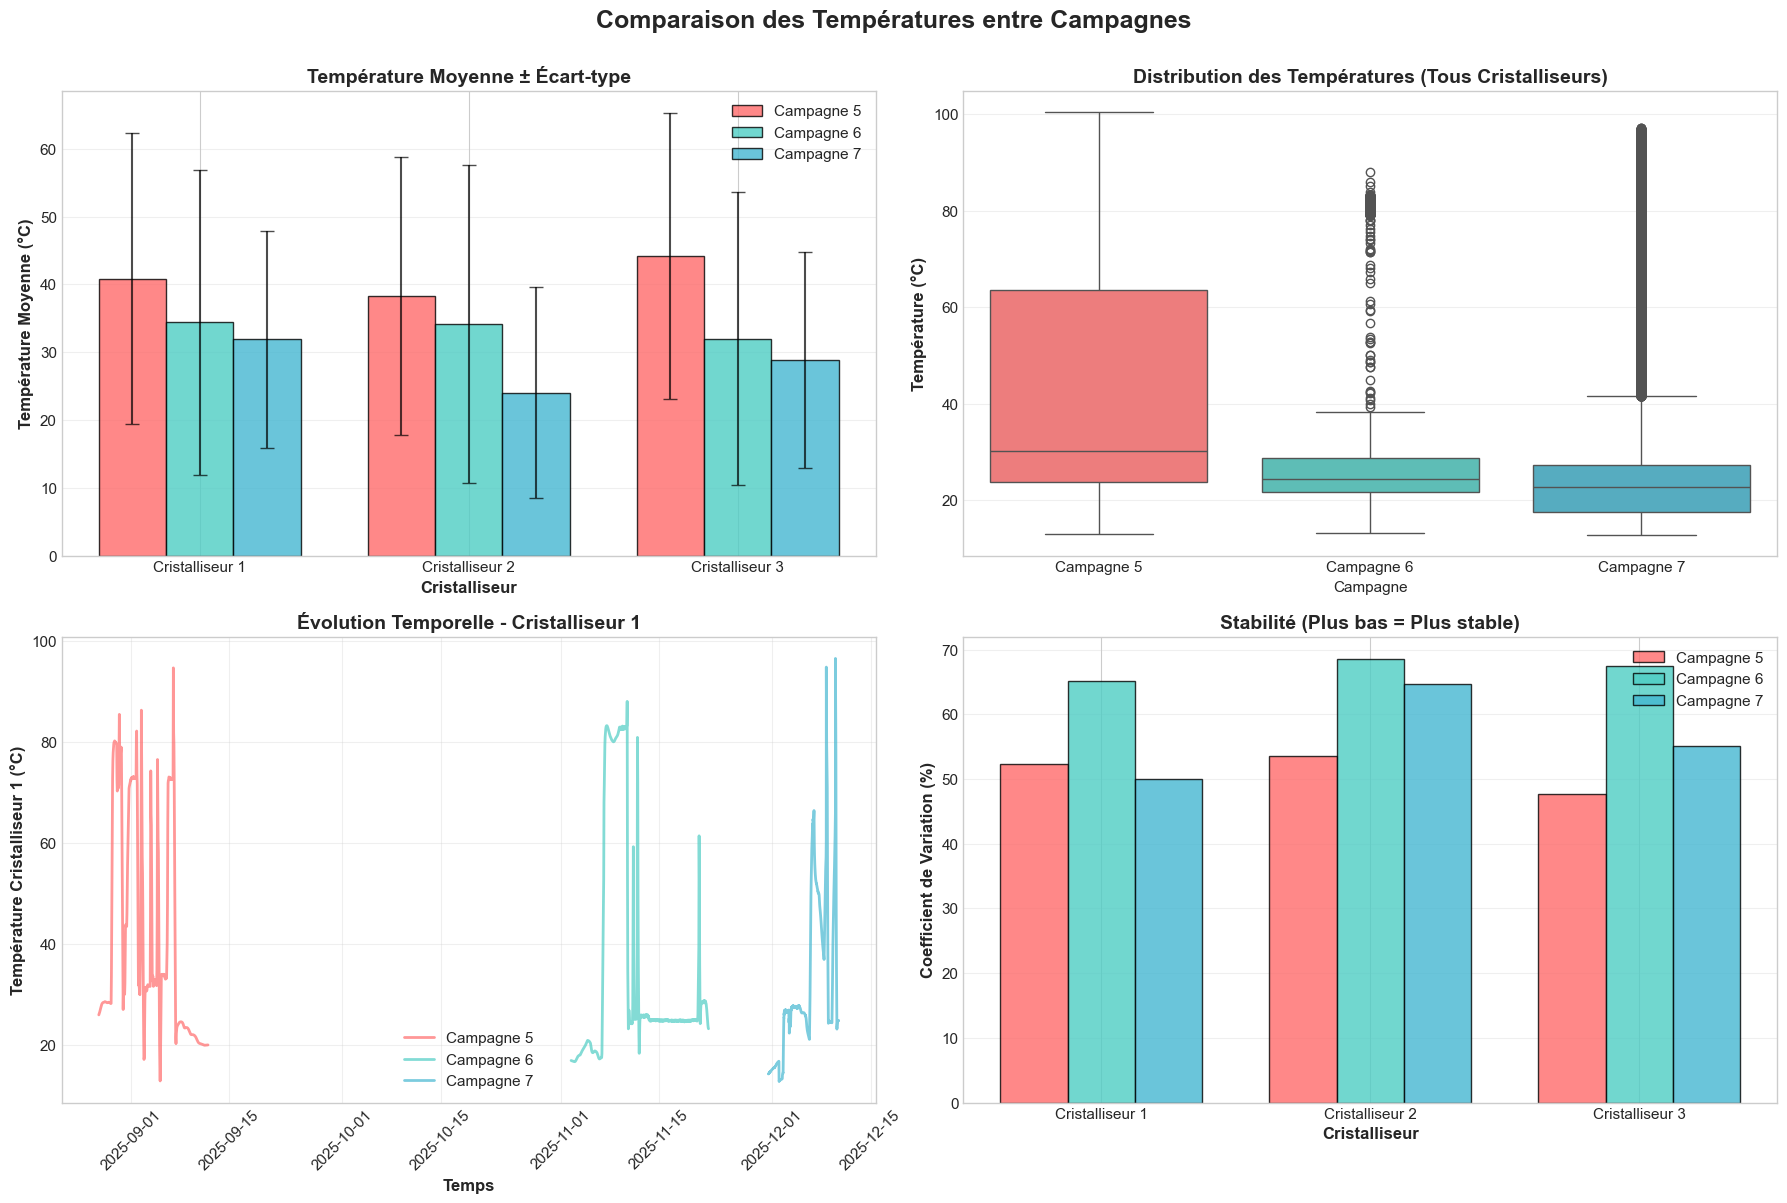

✓ Graphique sauvegardé: outputs/figures/09_campaign_temperature_comparison.png


In [15]:
# Comparaison des températures moyennes par campagne et cristalliseur
campaigns = ['Campagne 5', 'Campagne 6', 'Campagne 7']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparaison des Températures entre Campagnes', fontsize=18, fontweight='bold', y=1.00)

# Graphique 1: Températures moyennes par campagne et cristalliseur
temp_data = []
for idx, (col, cryst) in enumerate(zip(temp_cols, crystallizers)):
    for campaign in campaigns:
        camp_data = all_data[all_data['CAMPAIGN'] == campaign]
        temp_data.append({
            'Campagne': campaign,
            'Cristalliseur': cryst,
            'Température Moyenne': camp_data[col].mean(),
            'Écart-type': camp_data[col].std()
        })

temp_df = pd.DataFrame(temp_data)

# Barplot avec erreurs
x = np.arange(len(crystallizers))
width = 0.25

for idx, (campaign, color) in enumerate(zip(campaigns, colors)):
    camp_temps = temp_df[temp_df['Campagne'] == campaign]
    axes[0, 0].bar(x + idx*width, camp_temps['Température Moyenne'], width, 
                   label=campaign, color=color, alpha=0.8, edgecolor='black')
    axes[0, 0].errorbar(x + idx*width, camp_temps['Température Moyenne'], 
                        yerr=camp_temps['Écart-type'], fmt='none', color='black', 
                        capsize=5, alpha=0.7)

axes[0, 0].set_xlabel('Cristalliseur', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Température Moyenne (°C)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Température Moyenne ± Écart-type', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x + width)
axes[0, 0].set_xticklabels(crystallizers)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Graphique 2: Boxplot des températures par campagne
all_temps = []
for col in temp_cols:
    for campaign in campaigns:
        camp_data = all_data[all_data['CAMPAIGN'] == campaign][col].dropna()
        all_temps.extend([{'Campagne': campaign, 'Température': t} for t in camp_data])

temps_df = pd.DataFrame(all_temps)
sns.boxplot(data=temps_df, x='Campagne', y='Température', ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Distribution des Températures (Tous Cristalliseurs)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Température (°C)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Graphique 3: Évolution temporelle par campagne (premier cristalliseur)
if temp_cols:
    first_temp_col = temp_cols[0]
    for campaign, color in zip(campaigns, colors):
        camp_data = all_data[all_data['CAMPAIGN'] == campaign]
        if 'TIMESTAMP' in camp_data.columns:
            valid_data = camp_data[camp_data[first_temp_col].notna()]
            if len(valid_data) > 0:
                axes[1, 0].plot(valid_data['TIMESTAMP'], valid_data[first_temp_col], 
                               label=campaign, alpha=0.7, linewidth=2, color=color)

axes[1, 0].set_xlabel('Temps', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel(f'Température {crystallizers[0]} (°C)', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'Évolution Temporelle - {crystallizers[0]}', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Graphique 4: Stabilité (coefficient de variation)
cv_data = []
for idx, (col, cryst) in enumerate(zip(temp_cols, crystallizers)):
    for campaign in campaigns:
        camp_data = all_data[all_data['CAMPAIGN'] == campaign]
        mean_val = camp_data[col].mean()
        std_val = camp_data[col].std()
        cv = (std_val / mean_val) * 100 if mean_val != 0 else 0
        cv_data.append({
            'Campagne': campaign,
            'Cristalliseur': cryst,
            'CV (%)': cv
        })

cv_df = pd.DataFrame(cv_data)

for idx, (campaign, color) in enumerate(zip(campaigns, colors)):
    camp_cv = cv_df[cv_df['Campagne'] == campaign]
    axes[1, 1].bar(x + idx*width, camp_cv['CV (%)'], width, 
                   label=campaign, color=color, alpha=0.8, edgecolor='black')

axes[1, 1].set_xlabel('Cristalliseur', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Coefficient de Variation (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Stabilité (Plus bas = Plus stable)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x + width)
axes[1, 1].set_xticklabels(crystallizers)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/09_campaign_temperature_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Graphique sauvegardé: outputs/figures/09_campaign_temperature_comparison.png')

---
## 4. Comparaison des Niveaux par Campagne

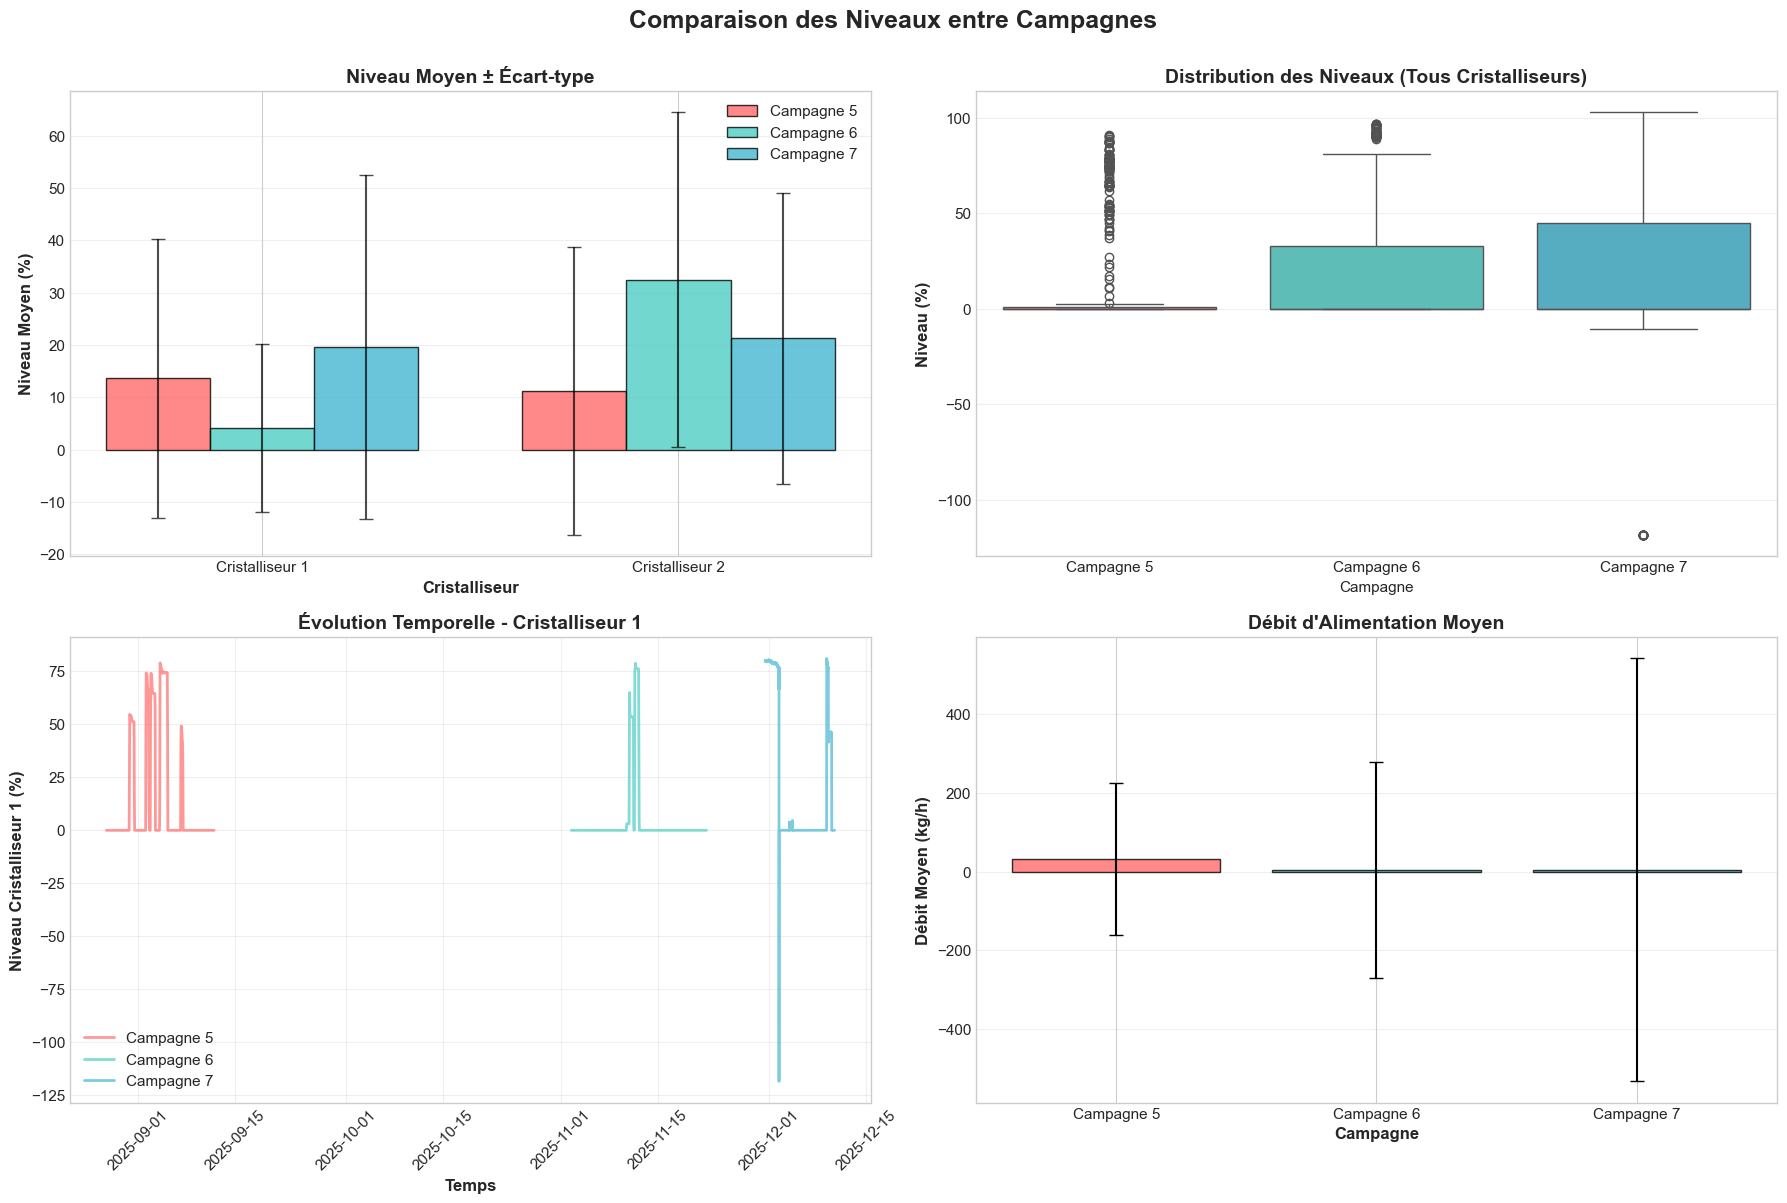

✓ Graphique sauvegardé: outputs/figures/10_campaign_level_comparison.png


In [16]:
# Comparaison des niveaux
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparaison des Niveaux entre Campagnes', fontsize=18, fontweight='bold', y=1.00)

# Créer les noms de cristalliseurs pour les niveaux
level_crystallizers = [f'Cristalliseur {i+1}' for i in range(len(level_cols))]

# Graphique 1: Niveaux moyens
level_data = []
for idx, (col, cryst) in enumerate(zip(level_cols, level_crystallizers)):
    for campaign in campaigns:
        camp_data = all_data[all_data['CAMPAIGN'] == campaign]
        level_data.append({
            'Campagne': campaign,
            'Cristalliseur': cryst,
            'Niveau Moyen': camp_data[col].mean(),
            'Écart-type': camp_data[col].std()
        })

level_df = pd.DataFrame(level_data)

x_level = np.arange(len(level_crystallizers))
width = 0.25

for idx, (campaign, color) in enumerate(zip(campaigns, colors)):
    camp_levels = level_df[level_df['Campagne'] == campaign]
    axes[0, 0].bar(x_level + idx*width, camp_levels['Niveau Moyen'], width, 
                   label=campaign, color=color, alpha=0.8, edgecolor='black')
    axes[0, 0].errorbar(x_level + idx*width, camp_levels['Niveau Moyen'], 
                        yerr=camp_levels['Écart-type'], fmt='none', color='black', 
                        capsize=5, alpha=0.7)

axes[0, 0].set_xlabel('Cristalliseur', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Niveau Moyen (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Niveau Moyen ± Écart-type', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x_level + width)
axes[0, 0].set_xticklabels(level_crystallizers)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Graphique 2: Boxplot des niveaux
all_levels = []
for col in level_cols:
    for campaign in campaigns:
        camp_data = all_data[all_data['CAMPAIGN'] == campaign][col].dropna()
        all_levels.extend([{'Campagne': campaign, 'Niveau': l} for l in camp_data])

levels_df = pd.DataFrame(all_levels)
sns.boxplot(data=levels_df, x='Campagne', y='Niveau', ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Distribution des Niveaux (Tous Cristalliseurs)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Niveau (%)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Graphique 3: Évolution temporelle (premier niveau disponible)
if level_cols:
    first_level_col = level_cols[0]
    for campaign, color in zip(campaigns, colors):
        camp_data = all_data[all_data['CAMPAIGN'] == campaign]
        if 'TIMESTAMP' in camp_data.columns:
            valid_data = camp_data[camp_data[first_level_col].notna()]
            if len(valid_data) > 0:
                axes[1, 0].plot(valid_data['TIMESTAMP'], valid_data[first_level_col], 
                               label=campaign, alpha=0.7, linewidth=2, color=color)

axes[1, 0].set_xlabel('Temps', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel(f'Niveau {level_crystallizers[0]} (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'Évolution Temporelle - {level_crystallizers[0]}', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Graphique 4: Comparaison du débit d'alimentation
if 'AVG_826FQR23' in all_data.columns:
    flow_data = []
    for campaign in campaigns:
        camp_data = all_data[all_data['CAMPAIGN'] == campaign]
        flow_data.append({
            'Campagne': campaign,
            'Débit Moyen': camp_data['AVG_826FQR23'].mean(),
            'Écart-type': camp_data['AVG_826FQR23'].std()
        })
    
    flow_df = pd.DataFrame(flow_data)
    x_flow = np.arange(len(campaigns))
    axes[1, 1].bar(x_flow, flow_df['Débit Moyen'], color=colors, alpha=0.8, edgecolor='black')
    axes[1, 1].errorbar(x_flow, flow_df['Débit Moyen'], yerr=flow_df['Écart-type'], 
                        fmt='none', color='black', capsize=5)
    axes[1, 1].set_xlabel('Campagne', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Débit Moyen (kg/h)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Débit d\'Alimentation Moyen', fontsize=14, fontweight='bold')
    axes[1, 1].set_xticks(x_flow)
    axes[1, 1].set_xticklabels(campaigns)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/10_campaign_level_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Graphique sauvegardé: outputs/figures/10_campaign_level_comparison.png')

---
## 5. Tableau Comparatif Détaillé

In [17]:
# Créer un tableau comparatif complet
comparison_table = []

for campaign in campaigns:
    camp_data = all_data[all_data['CAMPAIGN'] == campaign]
    
    row = {'Campagne': campaign}
    
    # Températures
    for idx, col in enumerate(temp_cols, 1):
        row[f'Temp_C{idx}_Moy'] = camp_data[col].mean()
        row[f'Temp_C{idx}_Std'] = camp_data[col].std()
    
    # Niveaux
    for idx, col in enumerate(level_cols, 1):
        row[f'Niveau_C{idx}_Moy'] = camp_data[col].mean()
        row[f'Niveau_C{idx}_Std'] = camp_data[col].std()
    
    # Débit
    if 'AVG_826FQR23' in camp_data.columns:
        row['Debit_Moy'] = camp_data['AVG_826FQR23'].mean()
        row['Debit_Std'] = camp_data['AVG_826FQR23'].std()
    
    comparison_table.append(row)

comparison_df = pd.DataFrame(comparison_table)

print('\n' + '='*100)
print('TABLEAU COMPARATIF DÉTAILLÉ DES CAMPAGNES')
print('='*100)
display(comparison_df.round(2))

# Sauvegarder le tableau
comparison_df.to_csv('outputs/data/campaign_comparison_table.csv', index=False)
print('\n✓ Tableau sauvegardé: outputs/data/campaign_comparison_table.csv')


TABLEAU COMPARATIF DÉTAILLÉ DES CAMPAGNES


,Campagne,Temp_C1_Moy,Temp_C1_Std,Temp_C2_Moy,Temp_C2_Std,Temp_C3_Moy,Temp_C3_Std,Niveau_C1_Moy,Niveau_C1_Std,Niveau_C2_Moy,Niveau_C2_Std,Debit_Moy,Debit_Std
0,Campagne 5,40.85,21.37,38.29,20.49,44.18,21.06,13.62,26.58,11.27,27.54,31.52,193.70
1,Campagne 6,34.41,22.44,34.22,23.44,32.01,21.59,4.22,16.03,32.52,32.01,3.98,275.75
2,Campagne 7,31.90,15.97,24.03,15.54,28.88,15.93,19.64,32.89,21.26,27.86,4.17,538.32



✓ Tableau sauvegardé: outputs/data/campaign_comparison_table.csv


---
## 6. Analyse des Performances Relatives


ANALYSE DES PERFORMANCES RELATIVES

Scores de Performance (0-100, plus élevé = meilleur):


,Campagne,Score_Stabilité,Score_Température,Score_Global,CV_Moyen (%),Déviation_Temp_Moy (°C)
2,Campagne 7,1.74,22.64,10.10,56.63,3.42
1,Campagne 6,1.47,12.43,5.85,67.05,7.05
0,Campagne 5,1.92,6.41,3.71,51.17,14.61


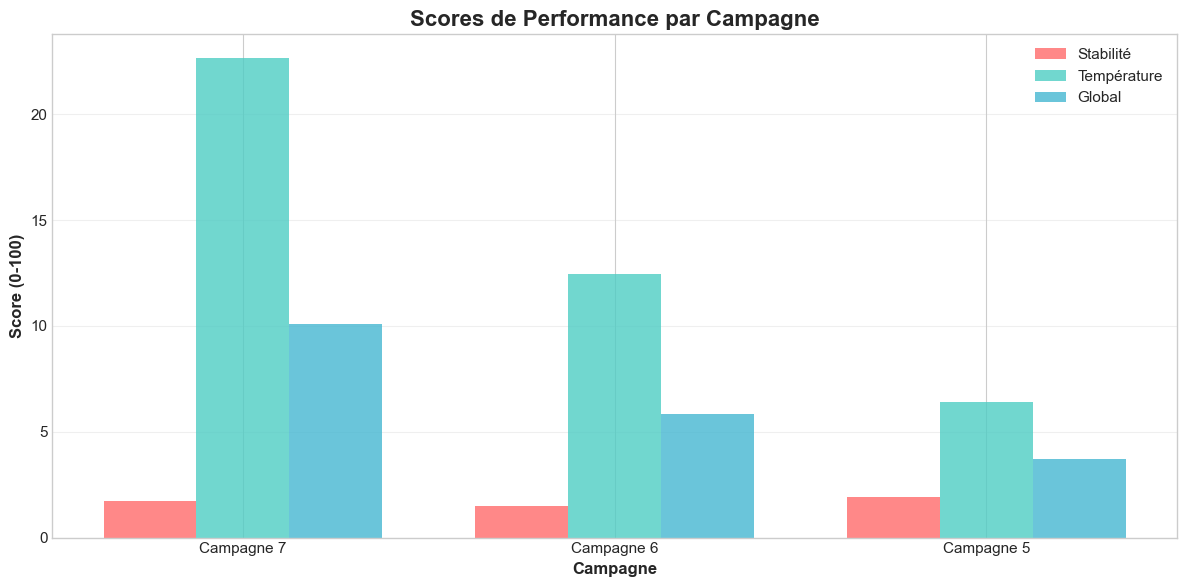


✓ Graphique sauvegardé: outputs/figures/11_campaign_performance_scores.png


In [18]:
# Calculer des scores de performance
print('\n' + '='*100)
print('ANALYSE DES PERFORMANCES RELATIVES')
print('='*100)

performance_scores = []

for campaign in campaigns:
    camp_data = all_data[all_data['CAMPAIGN'] == campaign]
    
    # Score de stabilité (inverse du CV moyen)
    temp_cvs = []
    for col in temp_cols:
        mean_val = camp_data[col].mean()
        std_val = camp_data[col].std()
        if mean_val != 0 and not np.isnan(mean_val):
            temp_cvs.append((std_val / mean_val) * 100)
    
    avg_cv = np.mean(temp_cvs) if temp_cvs else 0
    stability_score = 100 / (1 + avg_cv) if avg_cv > 0 else 0
    
    # Score de température (proximité à la cible, supposons 26.5°C)
    target_temp = 26.5
    temp_deviations = []
    for col in temp_cols:
        mean_temp = camp_data[col].mean()
        if not np.isnan(mean_temp):
            temp_deviations.append(abs(mean_temp - target_temp))
    
    avg_deviation = np.mean(temp_deviations) if temp_deviations else 0
    temp_score = 100 / (1 + avg_deviation)
    
    # Score global (moyenne pondérée)
    global_score = (stability_score * 0.6 + temp_score * 0.4)
    
    performance_scores.append({
        'Campagne': campaign,
        'Score_Stabilité': stability_score,
        'Score_Température': temp_score,
        'Score_Global': global_score,
        'CV_Moyen (%)': avg_cv,
        'Déviation_Temp_Moy (°C)': avg_deviation
    })

perf_df = pd.DataFrame(performance_scores)
perf_df = perf_df.sort_values('Score_Global', ascending=False)

print('\nScores de Performance (0-100, plus élevé = meilleur):')
display(perf_df.round(2))

# Visualisation des scores
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(campaigns))
width = 0.25

ax.bar(x_pos - width, perf_df['Score_Stabilité'], width, label='Stabilité', color='#FF6B6B', alpha=0.8)
ax.bar(x_pos, perf_df['Score_Température'], width, label='Température', color='#4ECDC4', alpha=0.8)
ax.bar(x_pos + width, perf_df['Score_Global'], width, label='Global', color='#45B7D1', alpha=0.8)

ax.set_xlabel('Campagne', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (0-100)', fontsize=12, fontweight='bold')
ax.set_title('Scores de Performance par Campagne', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(perf_df['Campagne'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/11_campaign_performance_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Graphique sauvegardé: outputs/figures/11_campaign_performance_scores.png')

---
## 7. Heatmap Comparative Multi-Variables

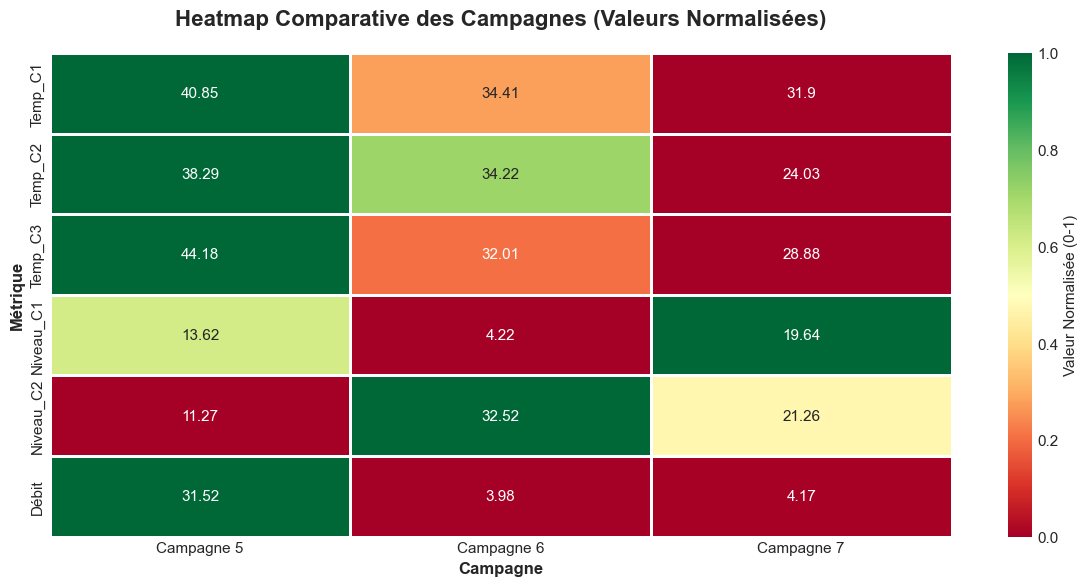

✓ Graphique sauvegardé: outputs/figures/12_campaign_heatmap.png


In [19]:
# Créer une heatmap comparative
heatmap_data = []

# Construire le dictionnaire de métriques dynamiquement
metrics = {}
for idx, col in enumerate(temp_cols, 1):
    metrics[f'Temp_C{idx}'] = col
for idx, col in enumerate(level_cols, 1):
    metrics[f'Niveau_C{idx}'] = col
if 'AVG_826FQR23' in all_data.columns:
    metrics['Débit'] = 'AVG_826FQR23'

for campaign in campaigns:
    camp_data = all_data[all_data['CAMPAIGN'] == campaign]
    row = {'Campagne': campaign}
    
    for metric_name, col_name in metrics.items():
        row[metric_name] = camp_data[col_name].mean()
    
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df = heatmap_df.set_index('Campagne')

# Normaliser les données pour la heatmap (0-1)
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_df),
    columns=heatmap_df.columns,
    index=heatmap_df.index
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_normalized.T, annot=heatmap_df.T.round(2), fmt='g', 
            cmap='RdYlGn', center=0.5, linewidths=2, linecolor='white',
            cbar_kws={'label': 'Valeur Normalisée (0-1)'})
plt.title('Heatmap Comparative des Campagnes (Valeurs Normalisées)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Métrique', fontsize=12, fontweight='bold')
plt.xlabel('Campagne', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/12_campaign_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Graphique sauvegardé: outputs/figures/12_campaign_heatmap.png')

---
## 9. Comparaison Isolée par Campagne avec Incrémentation


=== Génération des Graphiques Isolés par Campagne ===


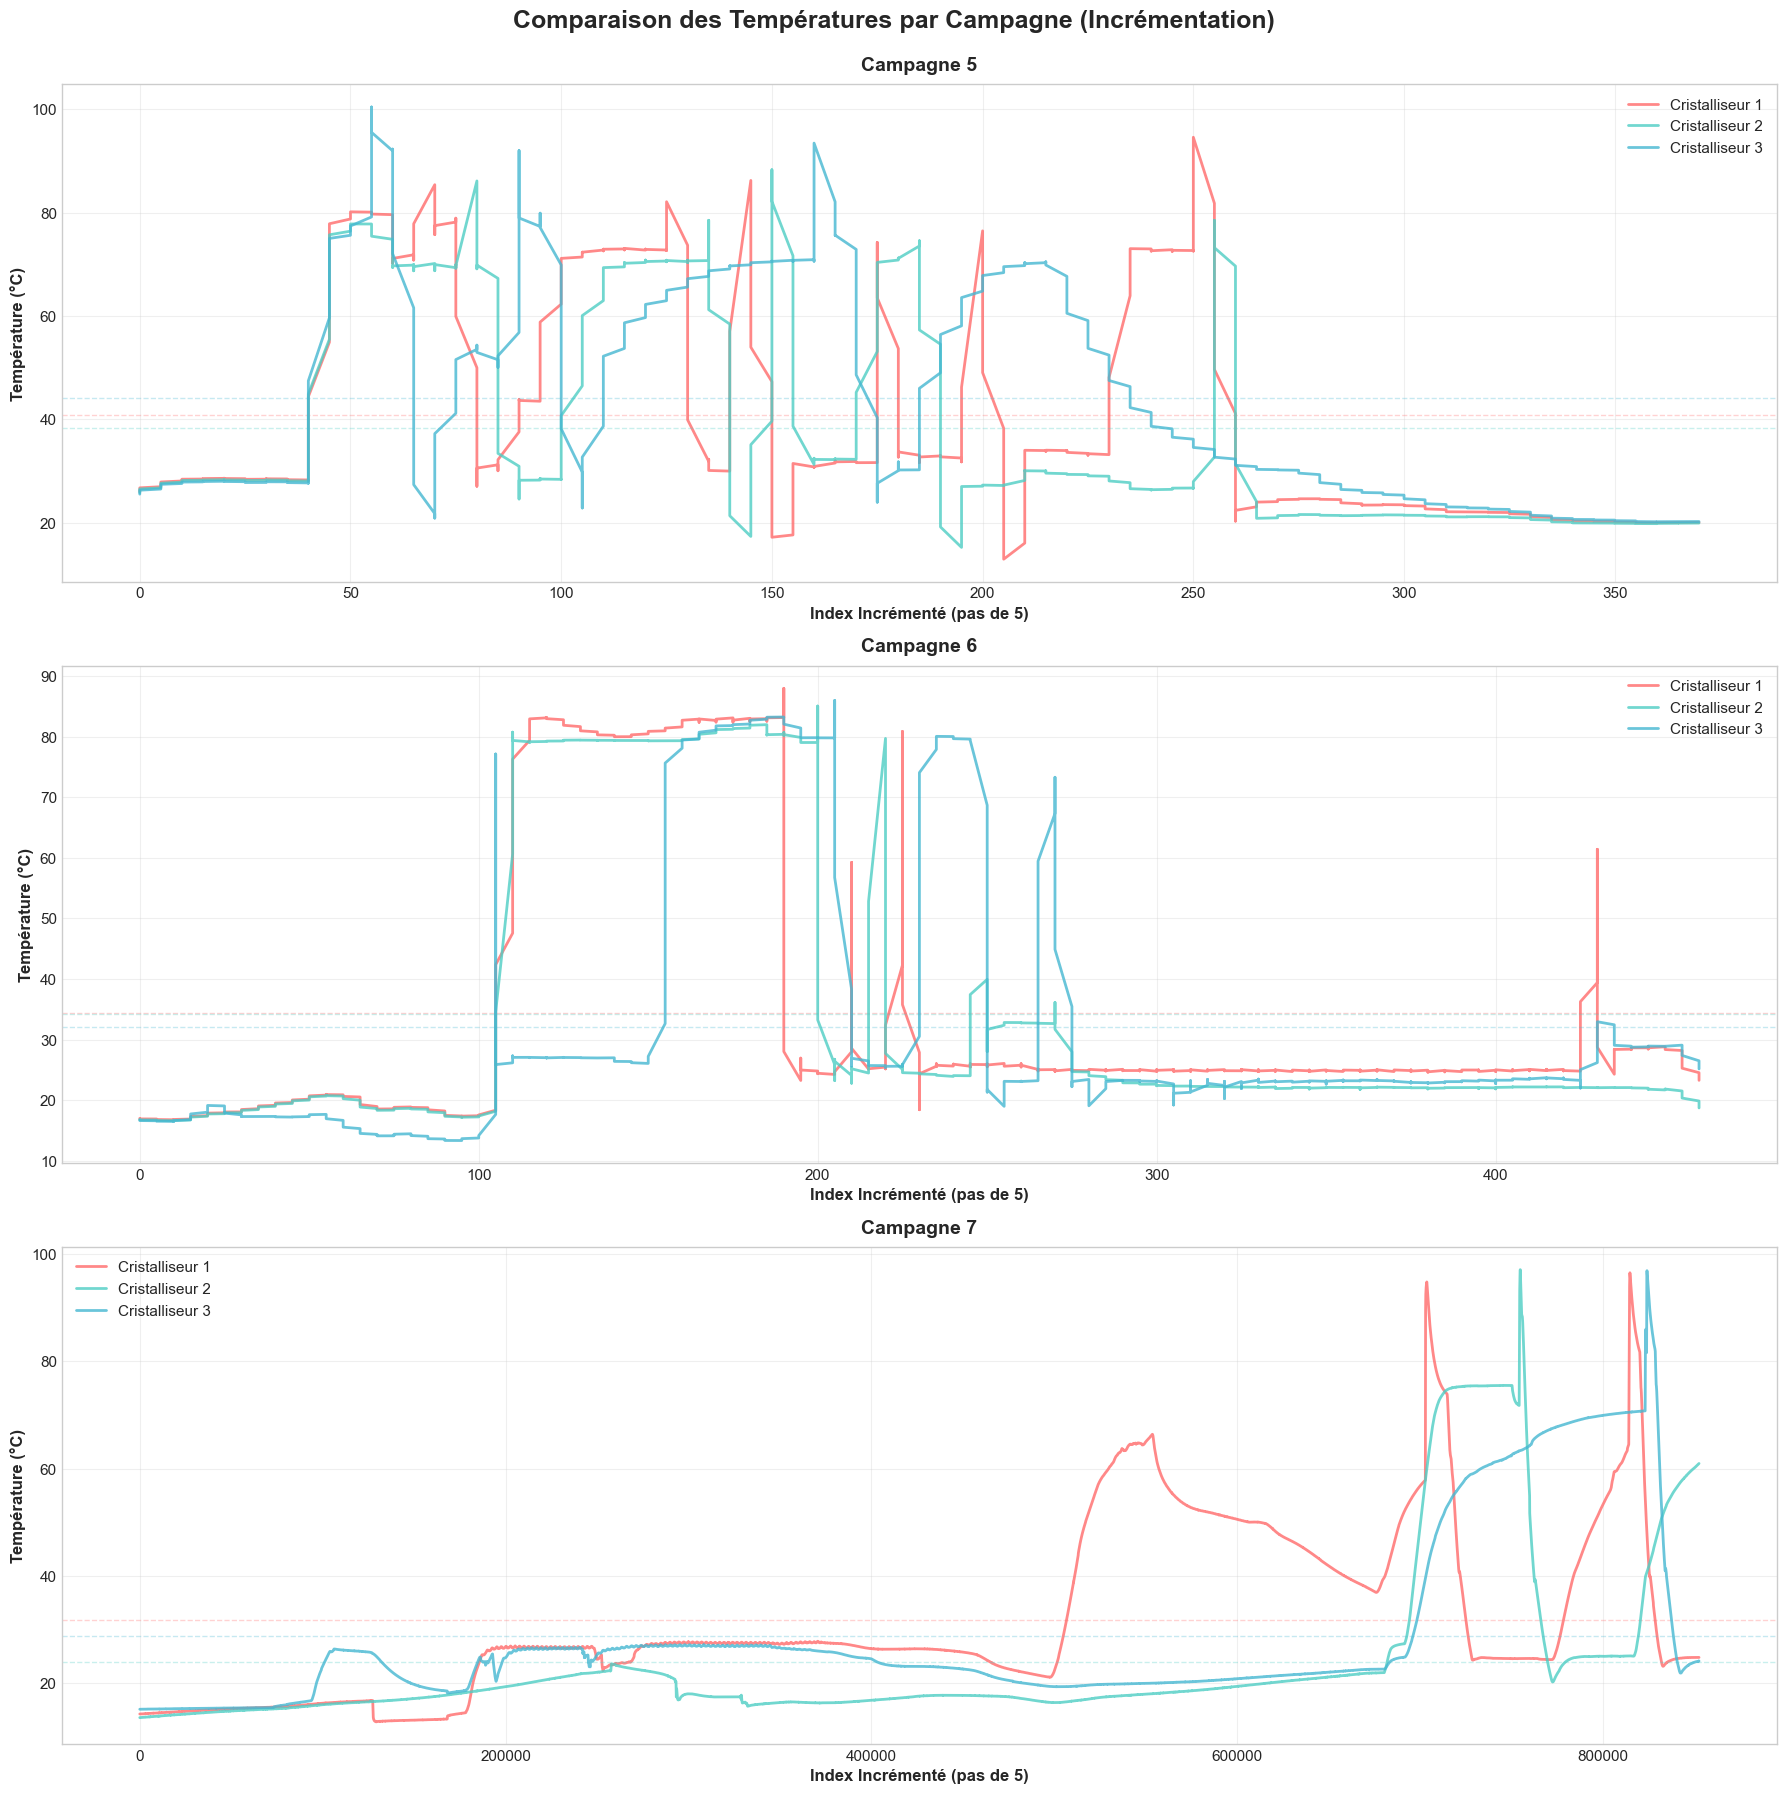

✓ Graphique sauvegardé: outputs/figures/13_campaign_isolated_temperatures.png


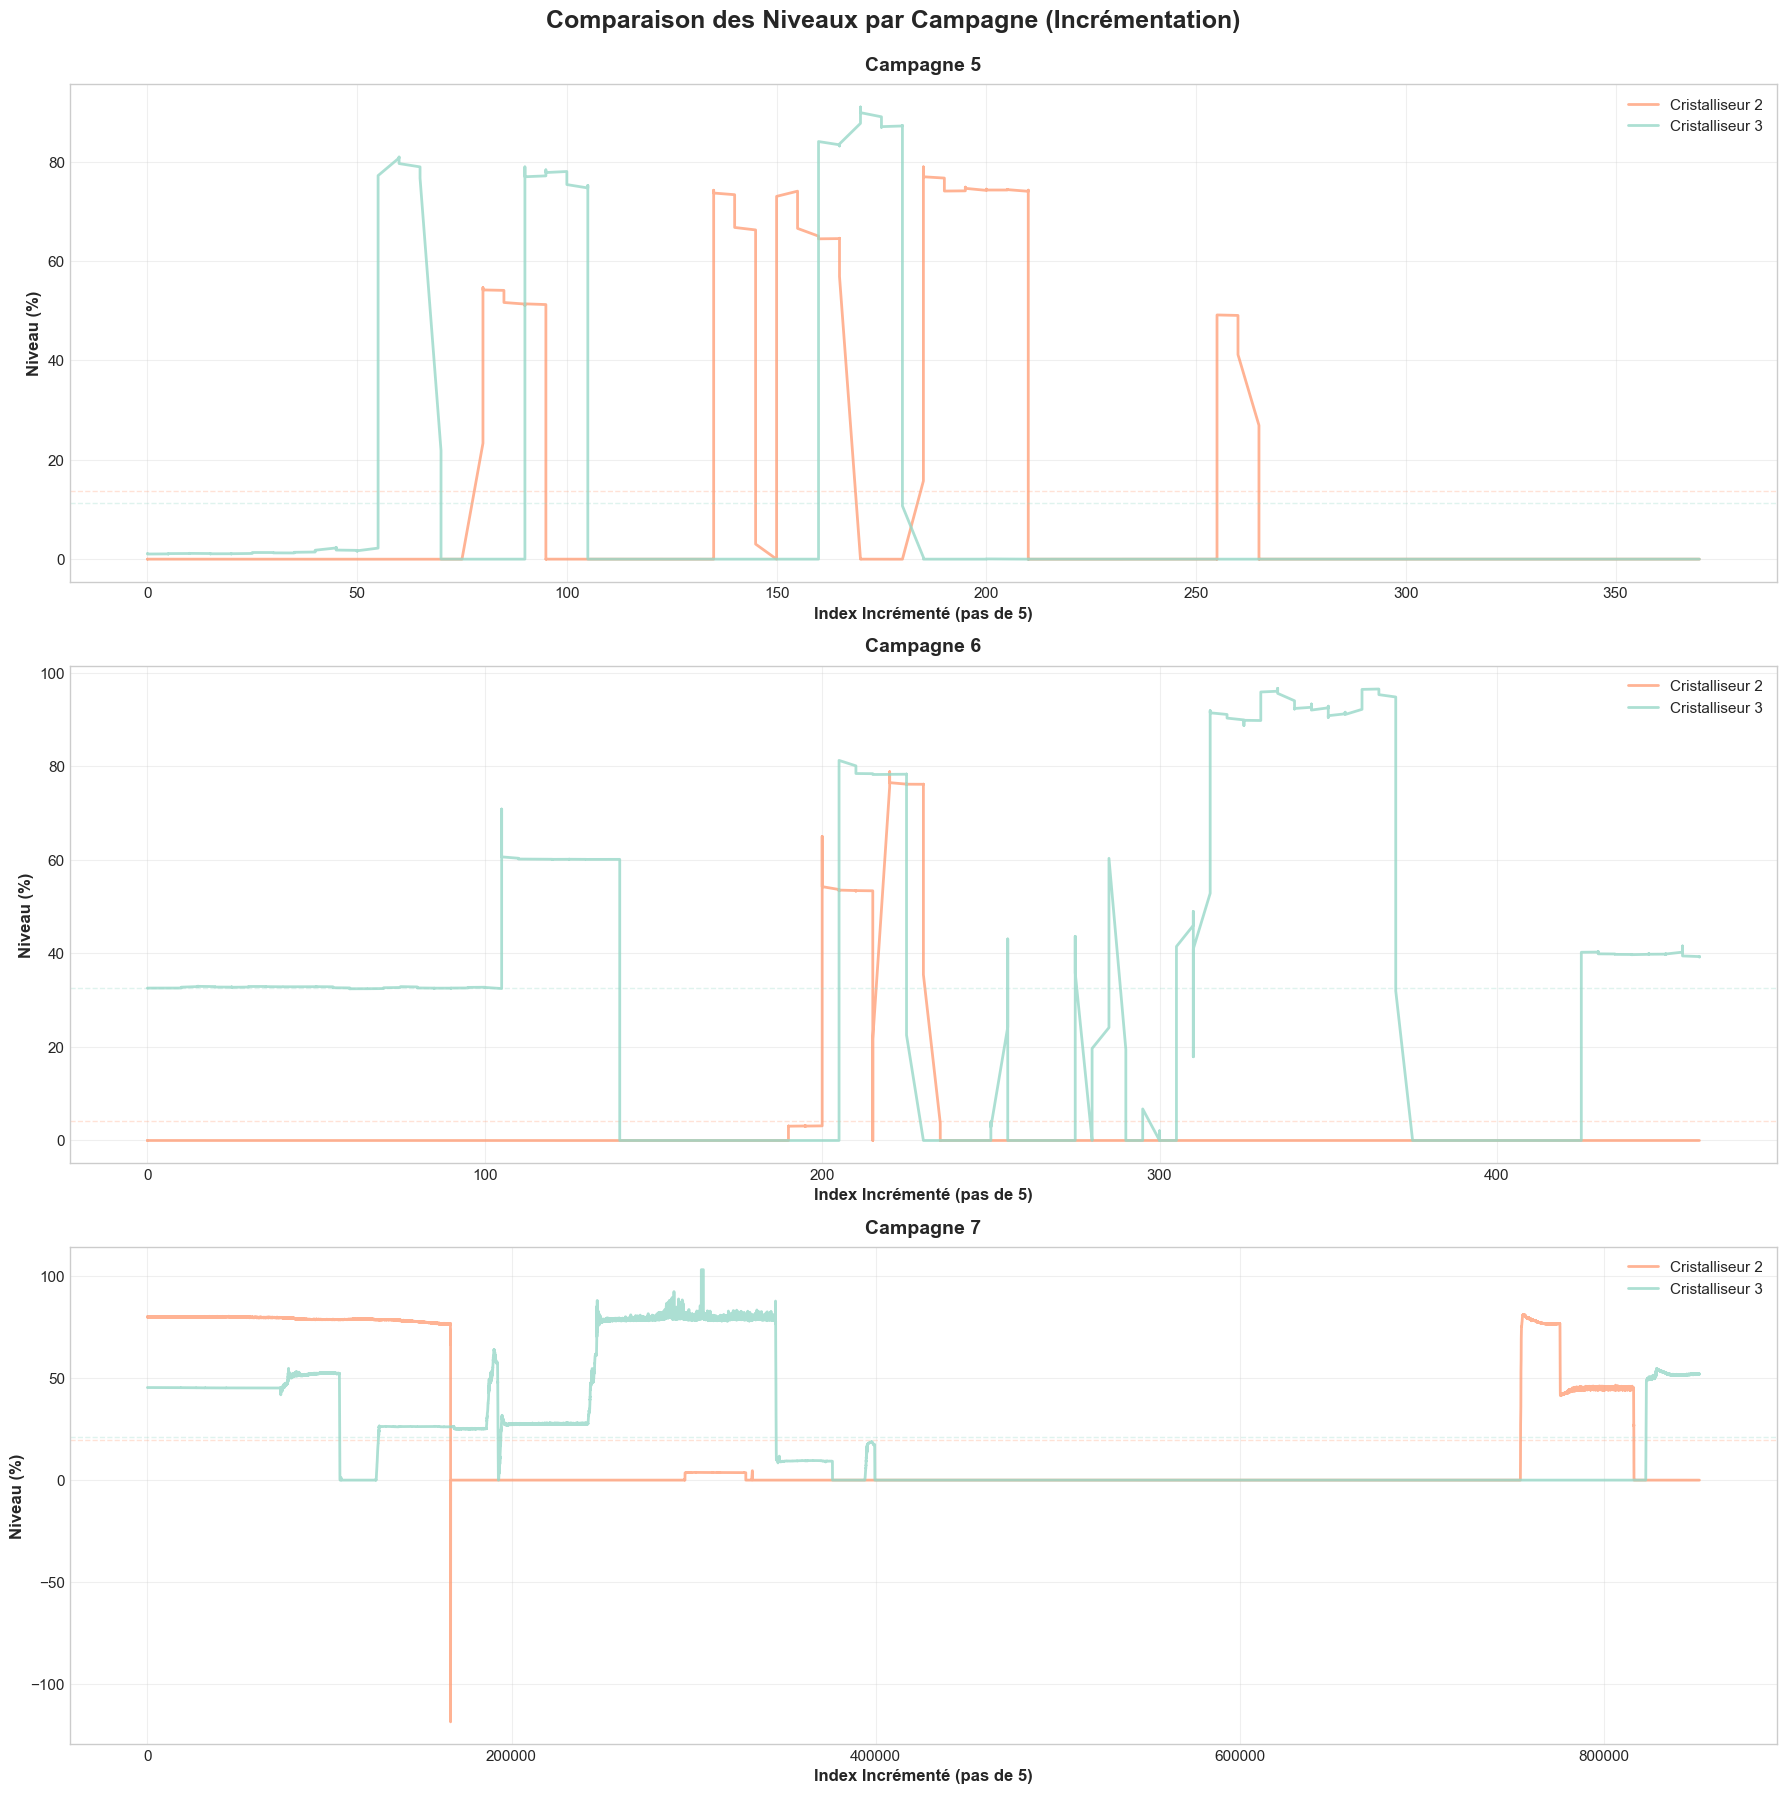

✓ Graphique sauvegardé: outputs/figures/14_campaign_isolated_levels.png


In [21]:
def plot_campaign_isolated_with_increment(all_data, campaigns, temp_cols, level_cols, increment=5):
    '''Visualise chaque campagne isolément avec incrémentation sur l\'axe X'''
    
    # Températures
    fig, axes = plt.subplots(len(campaigns), 1, figsize=(18, 6*len(campaigns)))
    if len(campaigns) == 1:
        axes = [axes]
    
    fig.suptitle('Comparaison des Températures par Campagne (Incrémentation)', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    colors_cryst = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for idx, campaign in enumerate(campaigns):
        camp_data = all_data[all_data['CAMPAIGN'] == campaign].copy()
        
        # Créer un index incrémenté
        camp_data = camp_data.reset_index(drop=True)
        camp_data['INCREMENT_INDEX'] = (camp_data.index // increment) * increment
        
        for col_idx, col in enumerate(temp_cols):
            if col in camp_data.columns:
                valid_data = camp_data[camp_data[col].notna()]
                if len(valid_data) > 0:
                    axes[idx].plot(valid_data['INCREMENT_INDEX'], valid_data[col], 
                                 label=f'Cristalliseur {col_idx+1}', 
                                 color=colors_cryst[col_idx % len(colors_cryst)],
                                 alpha=0.8, linewidth=2)
                    
                    # Ajouter la moyenne
                    mean_val = valid_data[col].mean()
                    axes[idx].axhline(y=mean_val, color=colors_cryst[col_idx % len(colors_cryst)], 
                                    linestyle='--', alpha=0.3, linewidth=1)
        
        axes[idx].set_xlabel(f'Index Incrémenté (pas de {increment})', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Température (°C)', fontsize=12, fontweight='bold')
        axes[idx].set_title(f'{campaign}', fontsize=14, fontweight='bold', pad=10)
        axes[idx].legend(loc='best', framealpha=0.9)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/figures/13_campaign_isolated_temperatures.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✓ Graphique sauvegardé: outputs/figures/13_campaign_isolated_temperatures.png')
    
    # Niveaux
    if level_cols:
        fig, axes = plt.subplots(len(campaigns), 1, figsize=(18, 6*len(campaigns)))
        if len(campaigns) == 1:
            axes = [axes]
        
        fig.suptitle('Comparaison des Niveaux par Campagne (Incrémentation)', 
                     fontsize=18, fontweight='bold', y=0.995)
        
        colors_level = ['#FFA07A', '#98D8C8', '#6C5CE7']
        
        for idx, campaign in enumerate(campaigns):
            camp_data = all_data[all_data['CAMPAIGN'] == campaign].copy()
            
            # Créer un index incrémenté
            camp_data = camp_data.reset_index(drop=True)
            camp_data['INCREMENT_INDEX'] = (camp_data.index // increment) * increment
            
            for col_idx, col in enumerate(level_cols):
                if col in camp_data.columns:
                    valid_data = camp_data[camp_data[col].notna()]
                    if len(valid_data) > 0:
                        axes[idx].plot(valid_data['INCREMENT_INDEX'], valid_data[col], 
                                     label=f'Cristalliseur {col_idx+2}',  # +2 car LR04 n\'existe pas
                                     color=colors_level[col_idx % len(colors_level)],
                                     alpha=0.8, linewidth=2)
                        
                        # Ajouter la moyenne
                        mean_val = valid_data[col].mean()
                        axes[idx].axhline(y=mean_val, color=colors_level[col_idx % len(colors_level)], 
                                        linestyle='--', alpha=0.3, linewidth=1)
            
            axes[idx].set_xlabel(f'Index Incrémenté (pas de {increment})', fontsize=12, fontweight='bold')
            axes[idx].set_ylabel('Niveau (%)', fontsize=12, fontweight='bold')
            axes[idx].set_title(f'{campaign}', fontsize=14, fontweight='bold', pad=10)
            axes[idx].legend(loc='best', framealpha=0.9)
            axes[idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outputs/figures/14_campaign_isolated_levels.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('✓ Graphique sauvegardé: outputs/figures/14_campaign_isolated_levels.png')

# Appeler la fonction
print('\n=== Génération des Graphiques Isolés par Campagne ===')
plot_campaign_isolated_with_increment(all_data, campaigns, temp_cols, level_cols, increment=5)

---
## 10. Comparaison Côte à Côte des Campagnes


=== Génération des Graphiques Côte à Côte ===


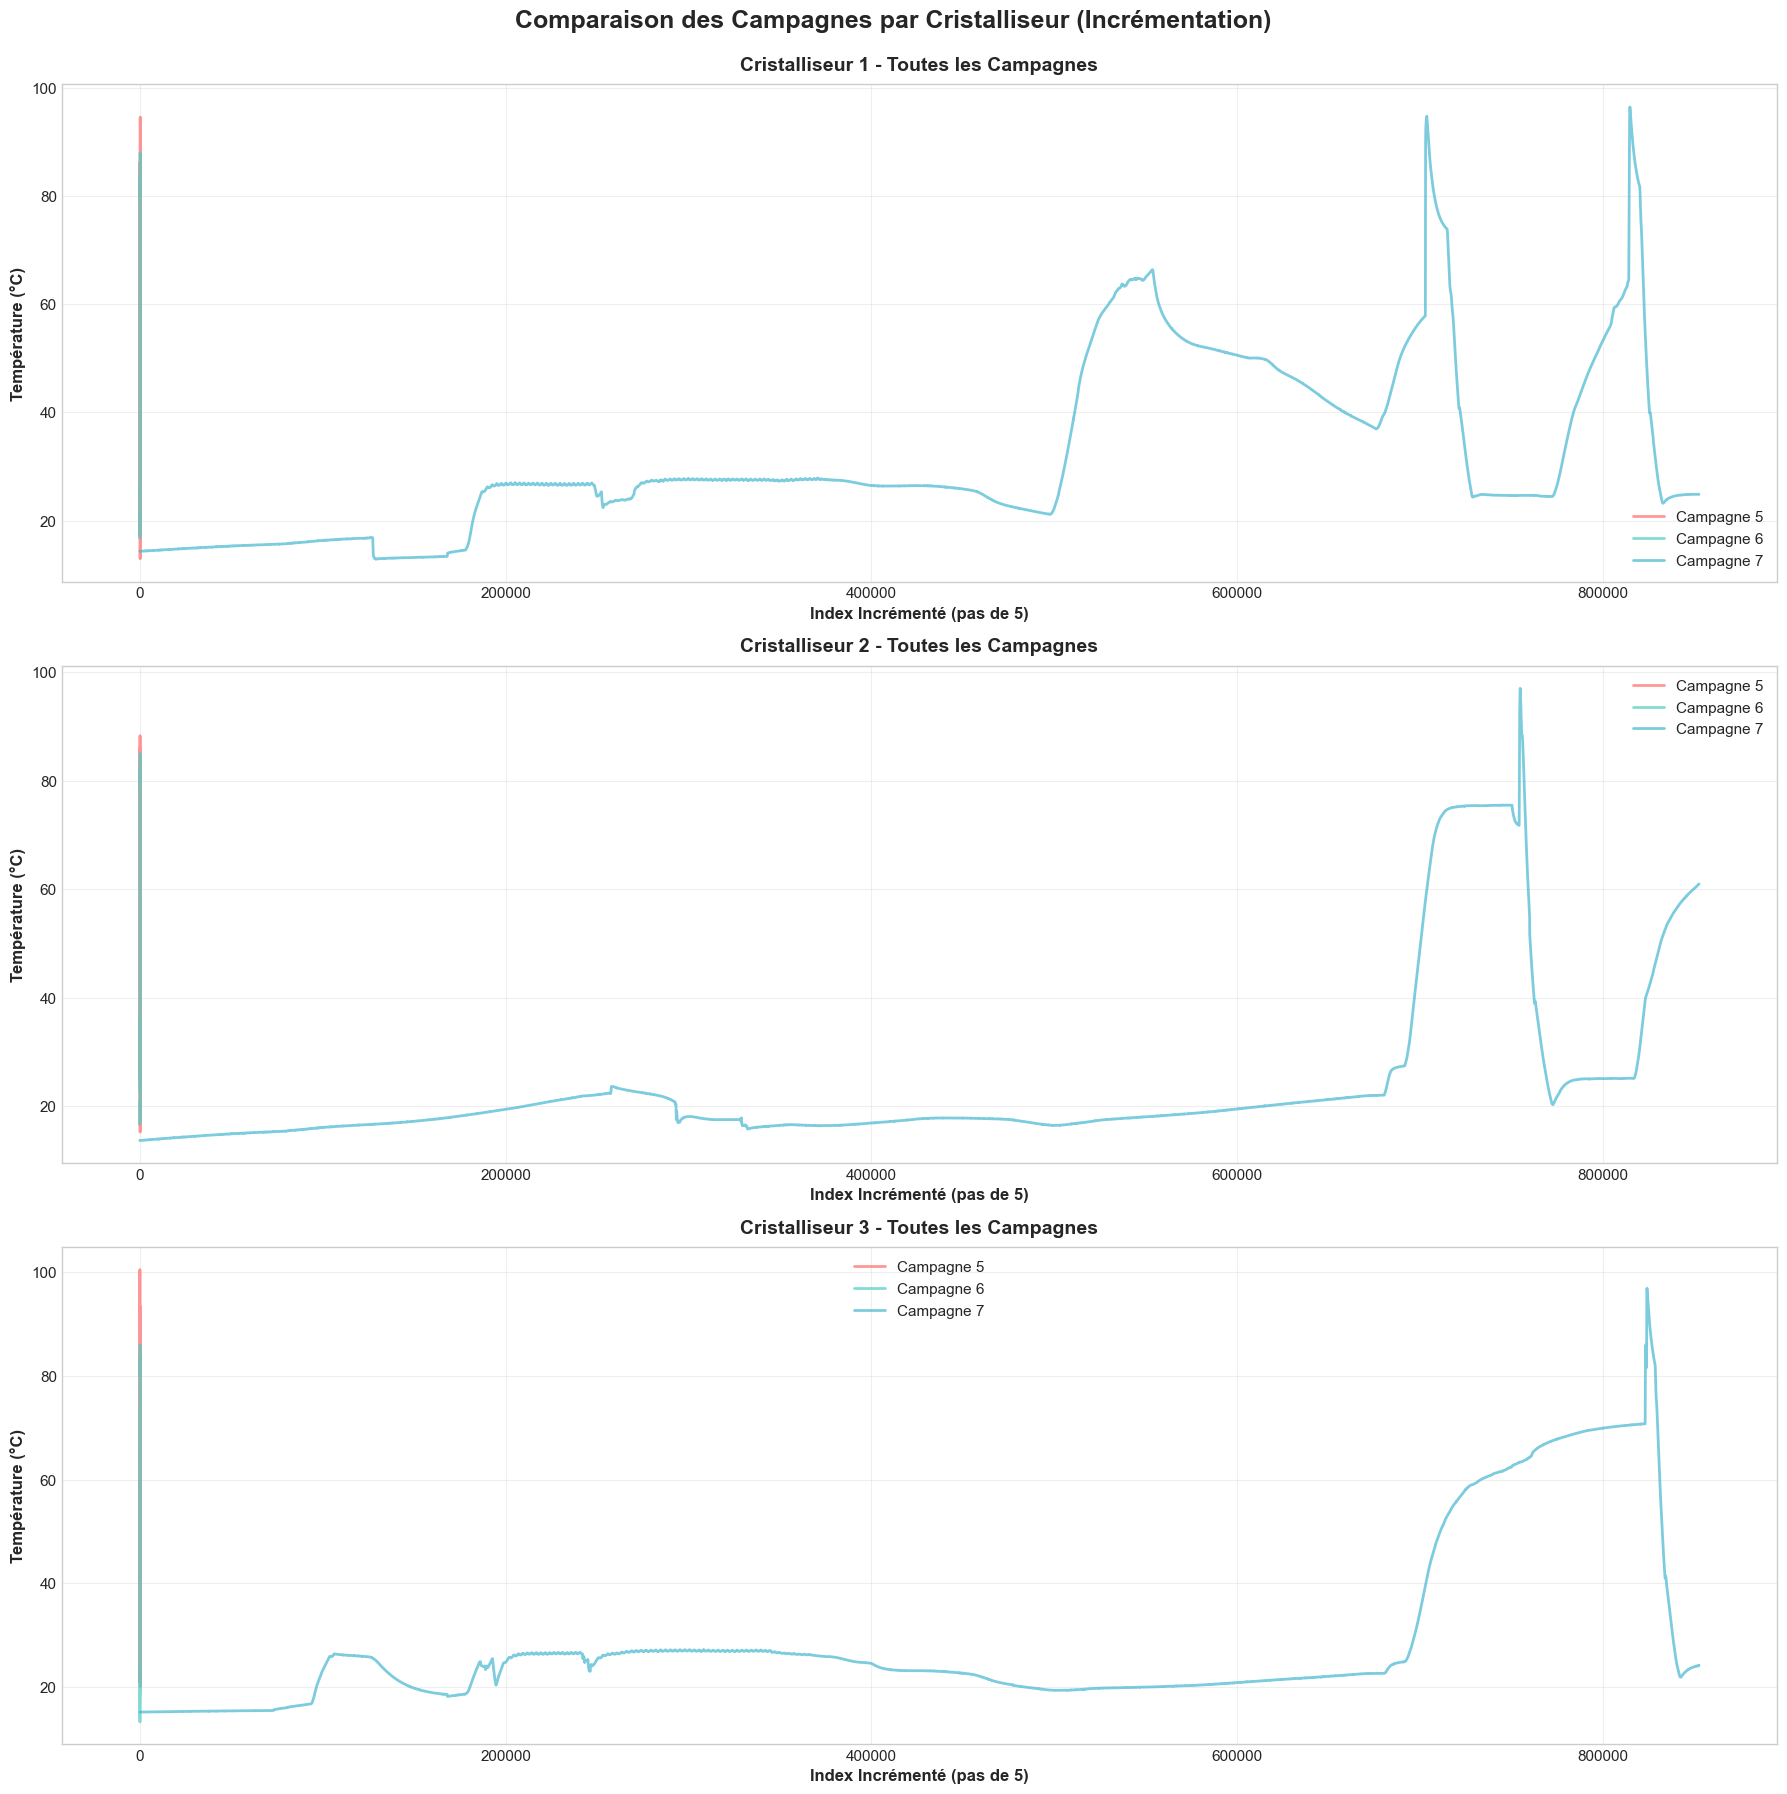

✓ Graphique sauvegardé: outputs/figures/15_campaigns_side_by_side.png


In [22]:
def plot_campaigns_side_by_side(all_data, campaigns, temp_cols, increment=5):
    '''Compare les campagnes côte à côte pour chaque cristalliseur'''
    
    n_crystallizers = len(temp_cols)
    fig, axes = plt.subplots(n_crystallizers, 1, figsize=(18, 6*n_crystallizers))
    if n_crystallizers == 1:
        axes = [axes]
    
    fig.suptitle('Comparaison des Campagnes par Cristalliseur (Incrémentation)', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    colors_camp = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for cryst_idx, col in enumerate(temp_cols):
        for camp_idx, campaign in enumerate(campaigns):
            camp_data = all_data[all_data['CAMPAIGN'] == campaign].copy()
            
            if col in camp_data.columns:
                # Créer un index incrémenté
                camp_data = camp_data.reset_index(drop=True)
                camp_data['INCREMENT_INDEX'] = (camp_data.index // increment) * increment
                
                valid_data = camp_data[camp_data[col].notna()]
                if len(valid_data) > 0:
                    axes[cryst_idx].plot(valid_data['INCREMENT_INDEX'], valid_data[col], 
                                       label=campaign, 
                                       color=colors_camp[camp_idx % len(colors_camp)],
                                       alpha=0.7, linewidth=2)
        
        axes[cryst_idx].set_xlabel(f'Index Incrémenté (pas de {increment})', fontsize=12, fontweight='bold')
        axes[cryst_idx].set_ylabel('Température (°C)', fontsize=12, fontweight='bold')
        axes[cryst_idx].set_title(f'Cristalliseur {cryst_idx+1} - Toutes les Campagnes', 
                                 fontsize=14, fontweight='bold', pad=10)
        axes[cryst_idx].legend(loc='best', framealpha=0.9)
        axes[cryst_idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/figures/15_campaigns_side_by_side.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✓ Graphique sauvegardé: outputs/figures/15_campaigns_side_by_side.png')

# Appeler la fonction
print('\n=== Génération des Graphiques Côte à Côte ===')
plot_campaigns_side_by_side(all_data, campaigns, temp_cols, increment=5)